In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn faker openpyxl

In [3]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta

fake = Faker()

n = 10000

categories = ["Electronics","Clothing","Groceries","Furniture","Sports"]
cities = ["Chennai","Bangalore","Hyderabad","Mumbai","Delhi"]

data = []

for i in range(n):
    price = random.randint(100,5000)
    quantity = random.randint(1,10)

    data.append([
        i+1,
        fake.date_between(start_date='-2y', end_date='today'),
        random.choice(categories),
        random.choice(cities),
        price,
        quantity,
        price*quantity
    ])

df = pd.DataFrame(data,columns=[
    "Order_ID",
    "Order_Date",
    "Category",
    "City",
    "Price",
    "Quantity",
    "Revenue"
])

df.to_csv("retail_data.csv",index=False)

df.head()

,Order_ID,Order_Date,Category,City,Price,Quantity,Revenue
0,1,2025-12-28,Clothing,Delhi,1925,6,11550
1,2,2025-03-30,Sports,Bangalore,4956,2,9912
2,3,2025-11-18,Clothing,Bangalore,2852,6,17112
3,4,2026-04-25,Sports,Hyderabad,4696,9,42264
4,5,2026-05-10,Electronics,Bangalore,2063,1,2063


In [4]:
df.shape

(10000, 7)

In [5]:
# Step 5 – Basic Data Analysis
# Dataset Information
print(df.info())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary Statistics
print("\nSummary:")
print(df.describe())

# Top 10 Records
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order_ID    10000 non-null  int64 
 1   Order_Date  10000 non-null  object
 2   Category    10000 non-null  object
 3   City        10000 non-null  object
 4   Price       10000 non-null  int64 
 5   Quantity    10000 non-null  int64 
 6   Revenue     10000 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 547.0+ KB
None

Missing Values:
Order_ID      0
Order_Date    0
Category      0
City          0
Price         0
Quantity      0
Revenue       0
dtype: int64

Summary:
          Order_ID        Price      Quantity       Revenue
count  10000.00000  10000.00000  10000.000000  10000.000000
mean    5000.50000   2565.91610      5.448000  14056.642700
std     2886.89568   1406.30589      2.877242  11480.597545
min        1.00000    100.00000      1.000000    103.000000
25%     2500.75000   135

,Order_ID,Order_Date,Category,City,Price,Quantity,Revenue
0,1,2025-12-28,Clothing,Delhi,1925,6,11550
1,2,2025-03-30,Sports,Bangalore,4956,2,9912
2,3,2025-11-18,Clothing,Bangalore,2852,6,17112
3,4,2026-04-25,Sports,Hyderabad,4696,9,42264
4,5,2026-05-10,Electronics,Bangalore,2063,1,2063
5,6,2025-03-12,Furniture,Hyderabad,4837,3,14511
6,7,2026-04-04,Sports,Bangalore,2806,4,11224
7,8,2024-07-13,Sports,Delhi,558,6,3348
8,9,2025-09-26,Groceries,Mumbai,4723,9,42507
9,10,2026-01-16,Sports,Hyderabad,2784,8,22272


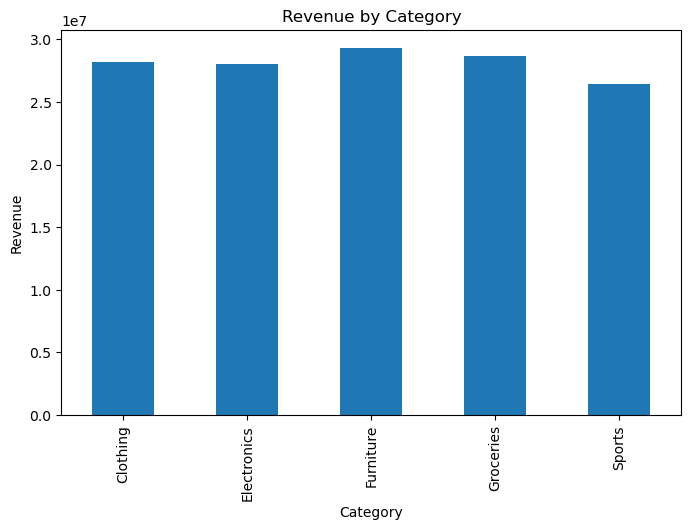

In [6]:
# Step 6 – Revenue Analysis
import matplotlib.pyplot as plt

# Revenue by Category
category_sales = df.groupby("Category")["Revenue"].sum()

category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

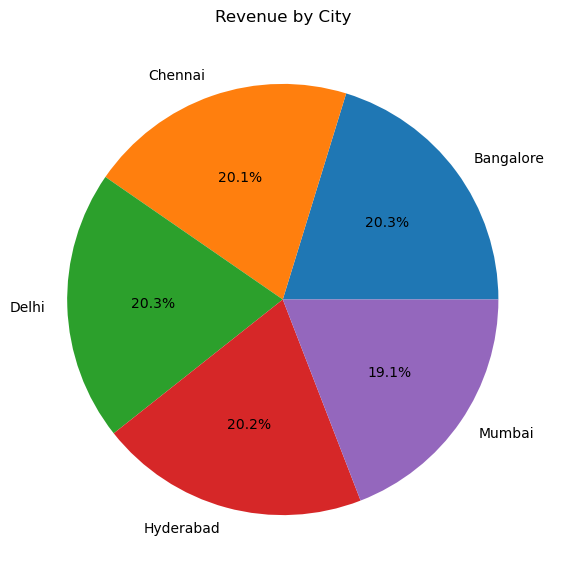

In [7]:
# Step 7 – Revenue by City
city_sales = df.groupby("City")["Revenue"].sum()

city_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(7,7))

plt.title("Revenue by City")
plt.ylabel("")
plt.show()

In [8]:
# Step 8 – Demand Forecasting (Linear Regression)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & Target
X = df[["Price", "Quantity"]]
y = df["Revenue"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [9]:
# Step 9 – Prediction:
predictions = model.predict(X_test)

print("First 10 Predictions:")
print(predictions[:10])

First 10 Predictions:
[ 8966.07872581 25998.47182958  1096.34903649 16621.11159613
  9490.85251027 27866.30593522 18453.56898575  2070.36161715
 13757.45118462 30831.25219422]


In [10]:
# Step 10 – Model Accuracy
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R2 Score :", round(r2, 2))
print("MAE :", round(mae, 2))

R2 Score : 0.88
MAE : 3031.47


In [12]:
# Step 11 – Save Final Dataset
df.to_excel("Retail_Dataset.xlsx", index=False)

print(" Dataset Saved Successfully")

 Dataset Saved Successfully


In [13]:
# Step 12 – Feature Engineering
# Convert Date
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# New Features
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Day"] = df["Order_Date"].dt.day
df["Weekday"] = df["Order_Date"].dt.day_name()

df.head()

,Order_ID,Order_Date,Category,City,Price,Quantity,Revenue,Year,Month,Day,Weekday
0,1,2025-12-28,Clothing,Delhi,1925,6,11550,2025,12,28,Sunday
1,2,2025-03-30,Sports,Bangalore,4956,2,9912,2025,3,30,Sunday
2,3,2025-11-18,Clothing,Bangalore,2852,6,17112,2025,11,18,Tuesday
3,4,2026-04-25,Sports,Hyderabad,4696,9,42264,2026,4,25,Saturday
4,5,2026-05-10,Electronics,Bangalore,2063,1,2063,2026,5,10,Sunday


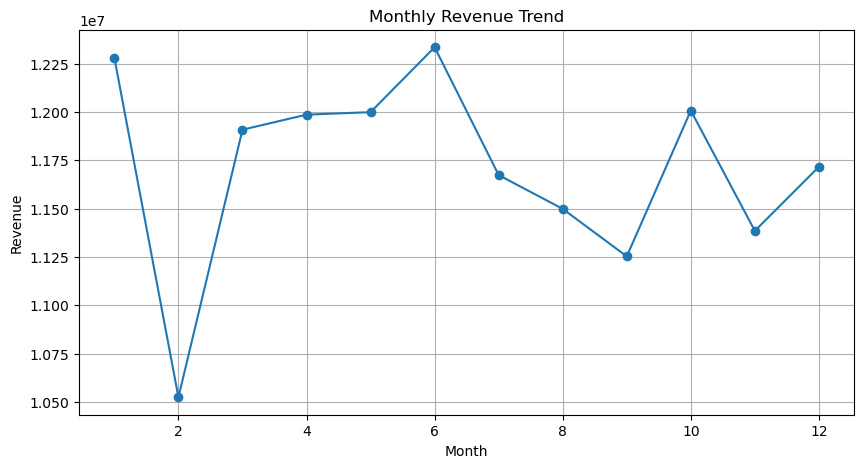

In [14]:
# Step 13 – Monthly Sales Trend
import matplotlib.pyplot as plt

monthly_sales = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [19]:
#Step 14 – Top 10 Products
products = [
    "Laptop","Phone","TV","Shoes","Watch",
    "Headphones","Tablet","Bag","Camera","Keyboard"
]

df["Product"] = np.random.choice(products, len(df))

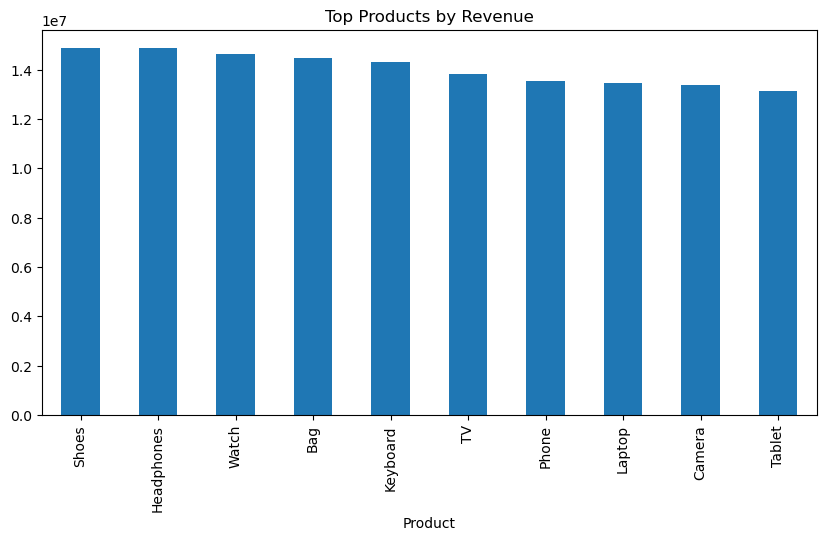

In [18]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top Products by Revenue")
plt.show()

In [21]:
# Step 15 – Save Final Dataset
df.to_csv("Retail_Dataset.csv", index=False)
df.to_excel("Retail_Dataset.xlsx", index=False)

print("Dataset Saved Successfully ")

Dataset Saved Successfully 


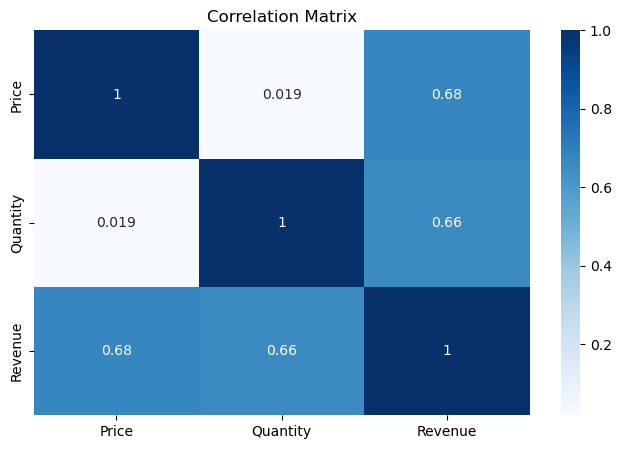

In [25]:
# Step 16 – Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Price","Quantity","Revenue"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()

In [26]:
# Step 17 – Top 5 Cities
city = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

print(city.head())

City
Delhi        28507371
Bangalore    28465221
Hyderabad    28417882
Chennai      28294086
Mumbai       26881867
Name: Revenue, dtype: int64
